# Professional Setup

In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import numpy as np  # linear algebra
import pandas as pd   # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import math

from warnings import filterwarnings
filterwarnings("ignore")

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("/kaggle/input/datasets/nalisha/mall-customer-segmentation-dataset-for-behavioral/Mall_Customers.csv")

# Quick preview
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Exploratory Data Analysis (EDA)

EDA is about understanding structure, distribution, relationships, and anomalies.

### Basic Information 

In [2]:
info_df = pd.DataFrame({
    'Column Name': df.columns,
    'Non-Null Count': df.notnull().sum().values,
    'Data Type': df.dtypes.values,
    "Duplicated Value": df.duplicated().sum(),
    'Missing Values': df.isnull().sum().values
    
})
# =====================================================

print("="*40)
print("📊 Dataset Structure:")
print("="*40)
display(info_df)
# =====================================================
print("="*75)
print("  ")
data = info_df.style.background_gradient(cmap='Blues')
display(data)

#======================================================
print(" ")
print("="*40)
print("Shape of dataset:", df.shape)
print("="*40)


📊 Dataset Structure:


,Column Name,Non-Null Count,Data Type,Duplicated Value,Missing Values
0,CustomerID,200,int64,0,0
1,Gender,200,object,0,0
2,Age,200,int64,0,0
3,Annual Income (k$),200,int64,0,0
4,Spending Score (1-100),200,int64,0,0


,Column Name,Non-Null Count,Data Type,Duplicated Value,Missing Values
0,CustomerID,200,int64,0,0
1,Gender,200,object,0,0
2,Age,200,int64,0,0
3,Annual Income (k$),200,int64,0,0
4,Spending Score (1-100),200,int64,0,0


 
Shape of dataset: (200, 5)


### Statistical Summary

In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Data Visualization



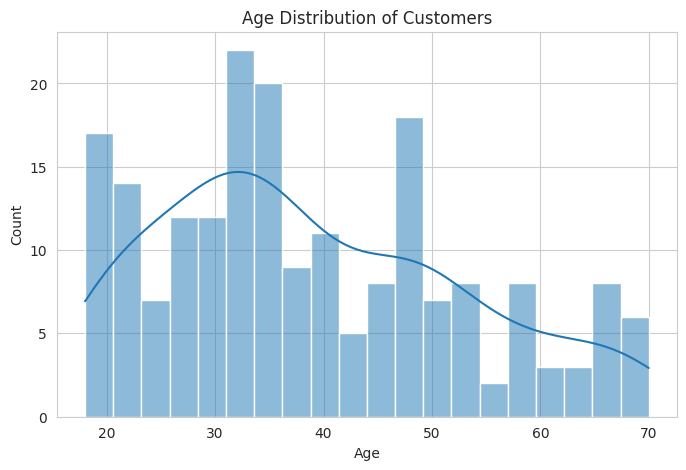

In [4]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Premium Gender Distribution

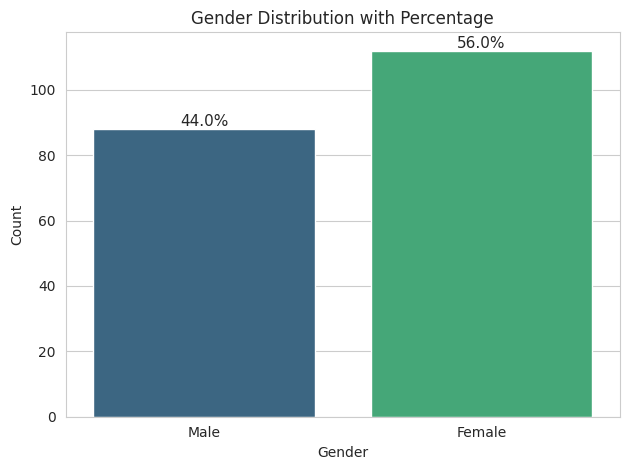

In [5]:
plt.figure()

ax = sns.countplot(
    x='Gender',
    data=df,
    palette="viridis"
)

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title("Gender Distribution with Percentage")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

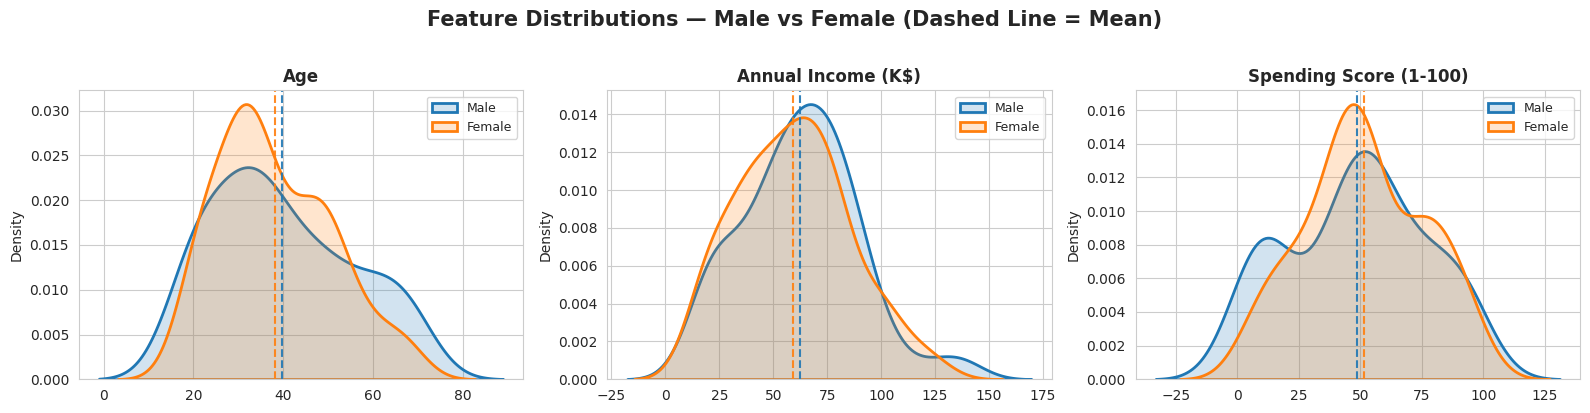

In [6]:
# ===============================
# Prepare Features
# ===============================

FEATURES = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
PALETTE = {
    'Male': '#1f77b4',
    'Female': '#ff7f0e'
}

ncols = 3
nrows = math.ceil(len(FEATURES) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()
# ===============================
# KDE + Mean Lines
# ===============================
for ax, feat in zip(axes, FEATURES):
    for gender, color in PALETTE.items():
        sub = df.loc[df['Gender'] == gender, feat].dropna()
        
    # KDE plot
        sns.kdeplot(
            sub,
            ax=ax,
            color=color,
            lw=2,
            label=gender,
            fill=True,
            alpha=0.2
        )
                # Mean line
        ax.axvline(
            sub.mean(),
            color=color,
            ls='--',
            lw=1.5,
            alpha=0.9
        )
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)
# Hide unused axes
for ax in axes[len(FEATURES):]:
    ax.set_visible(False)
plt.suptitle(
    'Feature Distributions — Male vs Female (Dashed Line = Mean)',
    fontsize=15,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()

The **KDE** distributions indicate subtle behavioral differences across gender groups. While income distribution remains relatively balanced, spending score shows mild variation, suggesting potential differences in consumption behavior. The dashed **mean lines further highlight** these shifts.

### Income vs Spending

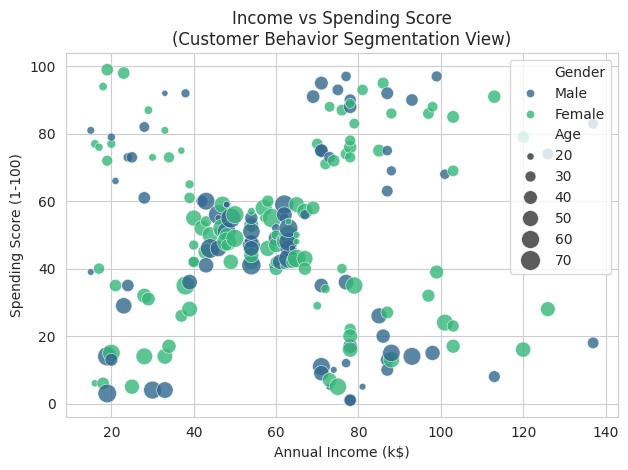

In [7]:
plt.figure()
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Gender',
    size='Age',
    sizes=(20, 200),
    palette='viridis',
    alpha=0.8,
    data=df
)

plt.title("Income vs Spending Score\n(Customer Behavior Segmentation View)")
plt.tight_layout()
plt.show()

# Heatmap

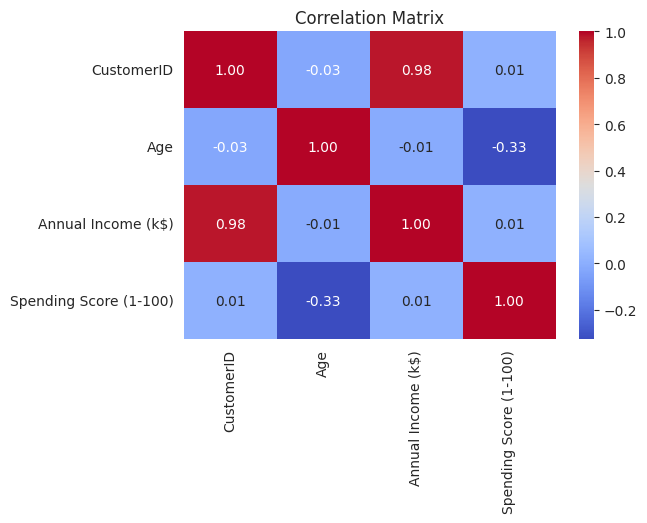

In [8]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

# Preprocessing

In [9]:
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})


# Feature Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=['Age', 'Income', 'Spending']
)

scaled_df.head()

,Age,Income,Spending
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


# Conclusion

In this analysis, we explored the Mall Customers dataset using Exploratory Data Analysis (EDA), preprocessing techniques, and advanced visualizations to understand customer behavior patterns.

This notebook demonstrates how raw data can be transformed into meaningful insights using proper EDA and visualization techniques.